# 02. Rolling-window baseline centiles

Velasco protocol, using the fixed train/test split. This notebook implements the model-free A2 baseline from `TASKS_day1.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

print("Project root:", ROOT)

Project root: d:\Hackathon\organoid-growth-charts


## Step 1. Load and inspect the working dataset

Each row is one HNOCA sequencing sample. We first check the table shape, column names, and a few example rows before filtering any protocol.

In [2]:
df_all = pd.read_csv(DATA / "hnoca_sample_composition.csv")

print("Shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())
df_all.head(3)

Shape: (322, 28)
Columns: ['sample', 'n_cells', 'age', 'publication', 'protocol', 'protocol_type', 'cell_line', 'frac_NPC_IP', 'frac_neuron', 'frac_glia', 'frac_neuroepithelium_PSC', 'l2_Astrocyte', 'l2_CP', 'l2_Dorsal Telencephalic IP', 'l2_Dorsal Telencephalic NPC', 'l2_Dorsal Telencephalic Neuron', 'l2_EC', 'l2_Glioblast', 'l2_MC', 'l2_Microglia', 'l2_NC Derivatives', 'l2_Neuroepithelium', 'l2_Non-telencephalic NPC', 'l2_Non-telencephalic Neuron', 'l2_OPC', 'l2_PSC', 'l2_Ventral Telencephalic NPC', 'l2_Ventral Telencephalic Neuron']


,sample,n_cells,age,publication,protocol,protocol_type,cell_line,frac_NPC_IP,frac_neuron,frac_glia,...,l2_MC,l2_Microglia,l2_NC Derivatives,l2_Neuroepithelium,l2_Non-telencephalic NPC,l2_Non-telencephalic Neuron,l2_OPC,l2_PSC,l2_Ventral Telencephalic NPC,l2_Ventral Telencephalic Neuron
0,homosapiens_None_2017_bdrhapsodywholetranscrip...,6800,105,"Birey, 2017","Pasca, 2015 (doi: 10.1038/nmeth.3415)",guided,custom_2242-1,0.287353,0.679265,0.022059,...,0.000588,0.0,0.000000,0.000000,0.018824,0.015735,0.000294,0.0,0.003971,0.010882
1,homosapiens_None_2017_bdrhapsodywholetranscrip...,4506,105,"Birey, 2017","Birey, 2017 (doi: 10.1038/nature22330)",guided,custom_2242-1,0.415224,0.413227,0.085220,...,0.009987,0.0,0.003329,0.073014,0.411008,0.325344,0.025078,0.0,0.001997,0.054594
2,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,9616,70,"Bhaduri, 2020","Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",guided,eWT-1323-4,0.085899,0.896319,0.015287,...,0.000000,0.0,0.000000,0.000000,0.001144,0.001872,0.000000,0.0,0.000000,0.000312


## Step 2. Filter the Velasco protocol

The protocol is the differentiation method; publication is the source study. We keep every row whose protocol name contains `Velasco`, then summarize its four publications.

In [3]:
velasco = df_all[df_all["protocol"].str.contains("Velasco", case=False, na=False)].copy()

publication_summary = (
    velasco.groupby("publication")
    .agg(
        n_samples=("sample", "size"),
        age_min=("age", "min"),
        age_max=("age", "max"),
    )
    .sort_index()
)

print("Velasco shape:", velasco.shape)
publication_summary

Velasco shape: (131, 28)


,n_samples,age_min,age_max
publication,,,
"Bhaduri, 2020",17,21,168
"Paulsen, 2022",54,28,190
"Uzquiano, 2022",39,23,192
"Velasco, 2019",21,101,190


## Step 3. Merge the fixed train/test split

The split was created once for the whole team and must not be regenerated. The baseline is estimated from train samples only; test samples are held out for evaluation.

In [4]:
split = pd.read_csv(DATA / "split_velasco.csv")
data = velasco.merge(split, on="sample", how="left", validate="one_to_one")

split_counts = data["split"].value_counts()
assert len(data) == 131, "The merge changed the number of Velasco samples."
assert data["split"].notna().all(), "Some Velasco samples have no split label."
assert split_counts.to_dict() == {"train": 105, "test": 26}, "Unexpected split sizes."

train = data[data["split"] == "train"].copy()
test = data[data["split"] == "test"].copy()

print("Split counts:")
print(split_counts)
pd.crosstab(data["publication"], data["split"], margins=True)

Split counts:
split
train    105
test      26
Name: count, dtype: int64


split,test,train,All
publication,,,
"Bhaduri, 2020",4,13,17
"Paulsen, 2022",12,42,54
"Uzquiano, 2022",6,33,39
"Velasco, 2019",4,17,21
All,26,105,131


## Step 4. Visualize the Velasco samples

This diagnostic plot shows the progenitor fraction over age, colours the four publications, and rings held-out test samples in black. It is displayed inline and is not saved as a file yet.

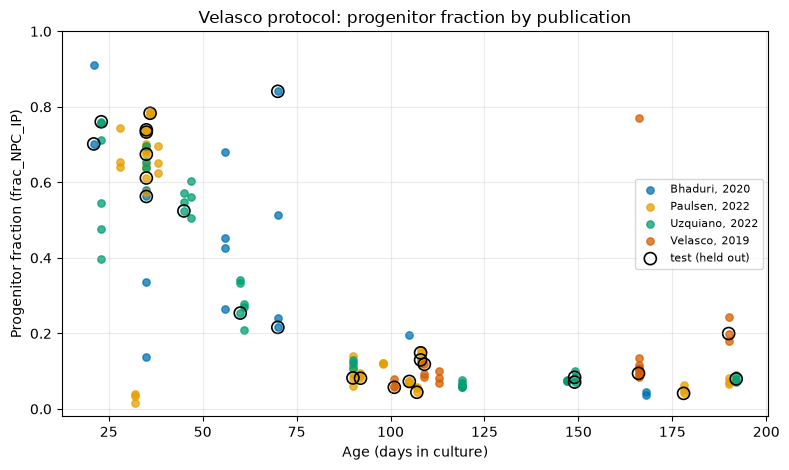

In [5]:
publication_colors = {
    "Bhaduri, 2020": "#0072B2",
    "Paulsen, 2022": "#E69F00",
    "Uzquiano, 2022": "#009E73",
    "Velasco, 2019": "#D55E00",
}

fig, ax = plt.subplots(figsize=(8, 4.8))

for publication, group in data.groupby("publication"):
    ax.scatter(
        group["age"],
        group["frac_NPC_IP"],
        s=28,
        alpha=0.75,
        color=publication_colors[publication],
        label=publication,
    )

ax.scatter(
    test["age"],
    test["frac_NPC_IP"],
    s=75,
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
    label="test (held out)",
)

ax.set(
    xlabel="Age (days in culture)",
    ylabel="Progenitor fraction (frac_NPC_IP)",
    title="Velasco protocol: progenitor fraction by publication",
)
ax.set_ylim(-0.02, 1.0)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 5. Work through one rolling window

Before calculating the whole curve, we apply the project method at day 100. Only train samples from day 85 through day 115 contribute to this local reference distribution.

In [6]:
target_age = 100
half_window = 15

local_train = train[
    train["age"].between(target_age - half_window, target_age + half_window)
].copy()

local_summary = local_train["frac_NPC_IP"].agg(["count", "mean", "std", "min", "max"])
local_centiles = local_train["frac_NPC_IP"].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
local_centiles.index = ["p5", "p25", "p50", "p75", "p95"]

print(f"Age window: {target_age - half_window} to {target_age + half_window} days")
print("Local summary:")
print(local_summary.round(3))
print("\nLocal centiles:")
print(local_centiles.round(3))

Age window: 85 to 115 days
Local summary:
count    29.000
mean      0.102
std       0.032
min       0.055
max       0.195
Name: frac_NPC_IP, dtype: float64

Local centiles:
p5     0.059
p25    0.079
p50    0.101
p75    0.122
p95    0.150
Name: frac_NPC_IP, dtype: float64


## Step 6. Define the adaptive rolling-window calculation

The project starts with a 15-day half-window. If fewer than eight train samples are available, the half-window grows by one day until the minimum sample count is reached.

In [7]:
CENTILE_LEVELS = [0.05, 0.25, 0.50, 0.75, 0.95]
CENTILE_NAMES = ["p5", "p25", "p50", "p75", "p95"]

def rolling_stats_at_age(train_data, target_age, initial_half_window=15, min_samples=8):
    """Calculate local train statistics for one target age, measured in days."""
    if len(train_data) < min_samples:
        raise ValueError("The train dataset has fewer rows than min_samples.")

    half_window = initial_half_window
    local = train_data[
        train_data["age"].between(target_age - half_window, target_age + half_window)
    ]

    while len(local) < min_samples:
        half_window += 1
        local = train_data[
            train_data["age"].between(target_age - half_window, target_age + half_window)
        ]

    values = local["frac_NPC_IP"]
    centiles = values.quantile(CENTILE_LEVELS)

    result = {
        "age": target_age,
        "half_window_days": half_window,
        "n_train": len(local),
        "mean": values.mean(),
        "sigma": values.std(),
    }
    result.update(dict(zip(CENTILE_NAMES, centiles)))
    return result

pd.Series(rolling_stats_at_age(train, target_age=100)).round(3)

age                 100.000
half_window_days     15.000
n_train              29.000
mean                  0.102
sigma                 0.032
p5                    0.059
p25                   0.079
p50                   0.101
p75                   0.122
p95                   0.150
dtype: float64

## Step 7. Calculate the full age grid

We now repeat the same train-only calculation for every integer age from day 20 through day 192. Diagnostic columns are kept in memory so we can verify sample counts and adaptive window widths before exporting results.

In [8]:
AGE_GRID = np.arange(20, 193)

rolling_stats = pd.DataFrame([
    rolling_stats_at_age(train, target_age=age)
    for age in AGE_GRID
])

assert len(rolling_stats) == 173
assert rolling_stats["n_train"].min() >= 8
assert rolling_stats["sigma"].notna().all()
assert (rolling_stats["sigma"] > 0).all()
centile_steps = np.diff(rolling_stats[CENTILE_NAMES].to_numpy(), axis=1)
assert (centile_steps >= 0).all()

print("Age rows:", len(rolling_stats), "days")
print("Half-window range:", rolling_stats["half_window_days"].min(), "to", rolling_stats["half_window_days"].max(), "days")
print("Train samples per window:", rolling_stats["n_train"].min(), "to", rolling_stats["n_train"].max(), "samples")
print("Age points with an expanded window:", int((rolling_stats["half_window_days"] > 15).sum()))

rolling_stats.iloc[[0, 1, 2, -3, -2, -1]].round(3)

Age rows: 173 days
Half-window range: 15 to 23 days
Train samples per window: 9 to 36 samples
Age points with an expanded window: 22


,age,half_window_days,n_train,mean,sigma,p5,p25,p50,p75,p95
0,20,15,26,0.551,0.244,0.035,0.493,0.644,0.696,0.754
1,21,15,28,0.568,0.243,0.036,0.527,0.650,0.704,0.784
2,22,15,28,0.568,0.243,0.036,0.527,0.650,0.704,0.784
170,190,15,9,0.102,0.065,0.054,0.067,0.072,0.089,0.218
171,191,15,9,0.102,0.065,0.054,0.067,0.072,0.089,0.218
172,192,15,9,0.102,0.065,0.054,0.067,0.072,0.089,0.218


## Step 8. Visually inspect the rolling centile curves

Before exporting files, we overlay the five train-derived centile curves on all 131 samples. The y-axis is formatted as the percentage of cells in each sample that are NPC/IP.

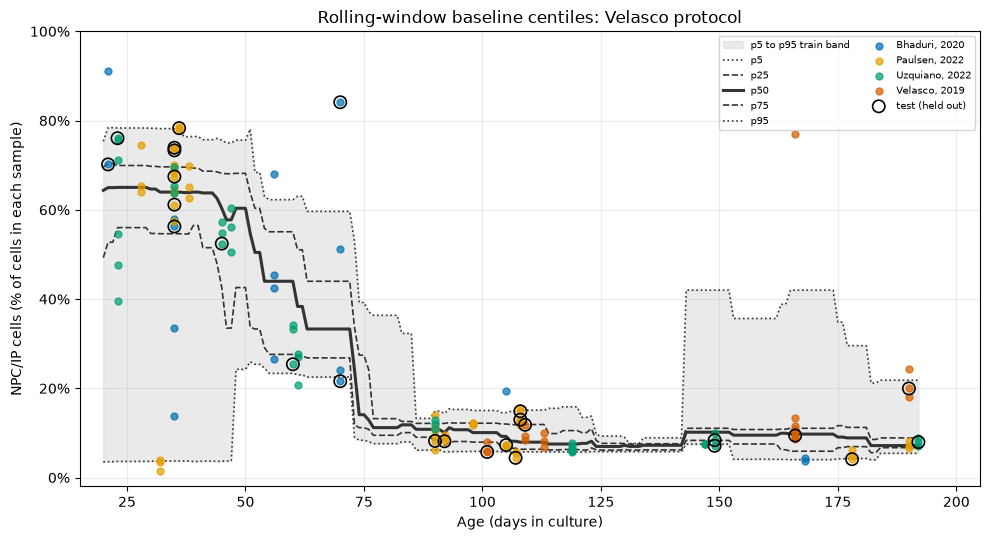

In [9]:
from matplotlib.ticker import PercentFormatter

centiles = rolling_stats[["age", "p5", "p25", "p50", "p75", "p95"]].copy()

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.fill_between(
    centiles["age"], centiles["p5"], centiles["p95"],
    color="0.85", alpha=0.55, label="p5 to p95 train band",
)

line_styles = {
    "p5": (":", 1.2),
    "p25": ("--", 1.2),
    "p50": ("-", 2.2),
    "p75": ("--", 1.2),
    "p95": (":", 1.2),
}
for column, (line_style, line_width) in line_styles.items():
    ax.plot(
        centiles["age"], centiles[column],
        linestyle=line_style, linewidth=line_width, color="0.20", label=column,
    )

for publication, group in data.groupby("publication"):
    ax.scatter(
        group["age"], group["frac_NPC_IP"],
        s=25, alpha=0.72, color=publication_colors[publication], label=publication, zorder=3,
    )

ax.scatter(
    test["age"], test["frac_NPC_IP"],
    s=78, facecolors="none", edgecolors="black", linewidths=1.2,
    label="test (held out)", zorder=4,
)

ax.set(
    xlabel="Age (days in culture)",
    ylabel="NPC/IP cells (% of cells in each sample)",
    title="Rolling-window baseline centiles: Velasco protocol",
    xlim=(15, 205),
    ylim=(-0.02, 1.0),
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.grid(alpha=0.25)
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## Step 9. Calculate sample-level z-scores

Each sample is compared with the train-only local reference distribution at its own age. The output includes all 131 samples for the shared file format, while model evaluation uses only the held-out test rows.

In [10]:
sample_local_stats = pd.DataFrame([
    rolling_stats_at_age(train, target_age=age)
    for age in data["age"]
]).reset_index(drop=True)

zscores = pd.DataFrame({
    "sample": data["sample"].to_numpy(),
    "age": data["age"].to_numpy(),
    "publication": data["publication"].to_numpy(),
    "split": data["split"].to_numpy(),
    "y": data["frac_NPC_IP"].to_numpy(),
    "mu": sample_local_stats["mean"].to_numpy(),
    "sigma": sample_local_stats["sigma"].to_numpy(),
})
zscores["z"] = (zscores["y"] - zscores["mu"]) / zscores["sigma"]

assert len(zscores) == 131
assert zscores["sample"].is_unique
assert zscores.notna().all().all()
assert np.isfinite(zscores[["mu", "sigma", "z"]]).all().all()
assert (zscores["sigma"] > 0).all()

test_zscores = zscores[zscores["split"] == "test"].copy()
test_summary = test_zscores["z"].agg(["count", "mean", "std", "skew", "min", "max"])

print("Test z-score summary (z has no unit):")
print(test_summary.round(3))
print("Test samples with |z| > 1.96:", int((test_zscores["z"].abs() > 1.96).sum()))

extreme_test_samples = pd.concat([
    test_zscores.nsmallest(3, "z"),
    test_zscores.nlargest(3, "z"),
])[["sample", "age", "publication", "y", "mu", "sigma", "z"]]
extreme_test_samples.round(3)

Test z-score summary (z has no unit):
count    26.000
mean      0.146
std       1.074
skew      0.966
min      -1.393
max       3.364
Name: z, dtype: float64
Test samples with |z| > 1.96: 1


,sample,age,publication,y,mu,sigma,z
30,homosapiens_telencephalon_2019_10x3v2_velascos...,101,"Velasco, 2019",0.057,0.102,0.032,-1.393
58,homosapiens_telencephalon_2022_10x3v3_paulsenb...,107,"Paulsen, 2022",0.044,0.092,0.034,-1.389
111,homosapiens_telencephalon_2022_10x3v3_uzquiano...,60,"Uzquiano, 2022",0.254,0.425,0.149,-1.146
2,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,70,"Bhaduri, 2020",0.841,0.365,0.142,3.364
52,homosapiens_telencephalon_2022_10x3v3_paulsenb...,108,"Paulsen, 2022",0.149,0.092,0.036,1.583
21,homosapiens_telencephalon_2019_10x3v2_velascos...,190,"Velasco, 2019",0.200,0.102,0.065,1.497


## Step 10. Export and validate the A2 deliverables

This cell writes the two shared-format CSV files and the baseline figure, then reads the CSV files back from disk to verify their schemas and row counts.

In [11]:
output_dir = RESULTS / "baseline_rolling"
output_dir.mkdir(parents=True, exist_ok=True)

centiles_path = output_dir / "centiles.csv"
zscores_path = output_dir / "zscores.csv"
figure_path = FIGURES / "baseline_rolling_velasco.png"

centiles.to_csv(centiles_path, index=False)
zscores.to_csv(zscores_path, index=False)
fig.savefig(figure_path, dpi=150, bbox_inches="tight")

centiles_check = pd.read_csv(centiles_path)
zscores_check = pd.read_csv(zscores_path)

assert centiles_check.columns.tolist() == ["age", "p5", "p25", "p50", "p75", "p95"]
assert len(centiles_check) == 173
assert centiles_check["age"].iloc[0] == 20
assert centiles_check["age"].iloc[-1] == 192
assert centiles_check.notna().all().all()

assert zscores_check.columns.tolist() == ["sample", "age", "publication", "split", "y", "mu", "sigma", "z"]
assert len(zscores_check) == 131
assert zscores_check["split"].value_counts().to_dict() == {"train": 105, "test": 26}
assert zscores_check.notna().all().all()
assert figure_path.exists() and figure_path.stat().st_size > 0

print(f"Centiles: {centiles_path} | {len(centiles_check)} rows x {len(centiles_check.columns)} columns")
print(f"Z-scores: {zscores_path} | {len(zscores_check)} rows x {len(zscores_check.columns)} columns")
print(f"Figure: {figure_path} | {figure_path.stat().st_size:,} bytes")

Centiles: d:\Hackathon\organoid-growth-charts\results\baseline_rolling\centiles.csv | 173 rows x 6 columns
Z-scores: d:\Hackathon\organoid-growth-charts\results\baseline_rolling\zscores.csv | 131 rows x 8 columns
Figure: d:\Hackathon\organoid-growth-charts\figures\baseline_rolling_velasco.png | 157,131 bytes
